# EDA — SK Hynix Defect Test Prediction
FDC Trace → C65 (Defect Test) 회귀 예측

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '문제1(하)/'
ANS_DIR  = '문제1_하_answer/'

## 0. 데이터 로드 & 타임스탬프 변환

In [3]:
train = pd.read_csv(DATA_DIR + 'train_data.csv')
valid_X = pd.read_csv(DATA_DIR + 'valid_X.csv')
test_X  = pd.read_csv(DATA_DIR + 'test_X.csv')
valid_Y_ans = pd.read_csv(ANS_DIR + 'valid_Y_answer.csv')
test_Y_ans  = pd.read_csv(ANS_DIR + 'test_Y_answer.csv')

# valid/test 컬럼 순서를 train에 맞춤 (C65 제외)
train_cols_no_target = [c for c in train.columns if c != 'C65']
valid_X = valid_X[train_cols_no_target]
test_X  = test_X[train_cols_no_target]

# Unix timestamp → datetime 변환
for df in [train, valid_X, test_X]:
    df['C10_dt'] = pd.to_datetime(df['C10'], unit='s')
    df['C39_dt'] = pd.to_datetime(df['C39'], unit='s')
    df['C40_dt'] = pd.to_datetime(df['C40'])

print(f"train : {train.shape} | WF수: {train.C64.nunique()}")
print(f"valid : {valid_X.shape} | WF수: {valid_X.C64.nunique()}")
print(f"test  : {test_X.shape} | WF수: {test_X.C64.nunique()}")
print()
print("시간 범위 확인:")
for name, df in [('train', train), ('valid', valid_X), ('test', test_X)]:
    print(f"  {name}: {df['C40_dt'].min()} ~ {df['C40_dt'].max()}")

train : (123614, 68) | WF수: 11939
valid : (20577, 67) | WF수: 1990
test  : (20510, 67) | WF수: 1990

시간 범위 확인:
  train: 2018-12-01 00:44:06.700000 ~ 2019-02-08 09:43:02.900000
  valid: 2018-12-01 00:46:06.700000 ~ 2019-02-08 09:41:08.900000
  test: 2018-12-01 00:57:31.600000 ~ 2019-02-08 09:35:29.700000


## 1. 컬럼 타입 · 카디널리티 · 상수 식별

In [4]:
col_info = pd.DataFrame({
    'dtype': train.dtypes,
    'nunique': train.nunique(),
    'null_count': train.isnull().sum(),
    'null_pct': (train.isnull().mean() * 100).round(2),
    'sample_value': train.iloc[0],
})

# 상수 컬럼 (nunique <= 1)
const_cols = col_info[col_info['nunique'] <= 1].index.tolist()
print(f"상수 컬럼 ({len(const_cols)}개): {const_cols}\n")

# 전부 결측 컬럼
all_na_cols = col_info[col_info['null_pct'] == 100].index.tolist()
print(f"전부 결측 컬럼: {all_na_cols}\n")

# object(범주형) 컬럼
obj_cols = col_info[col_info['dtype'] == 'object'].index.tolist()
print(f"문자열 컬럼 ({len(obj_cols)}개): {obj_cols}\n")

col_info.sort_values('null_pct', ascending=False)

상수 컬럼 (20개): ['C2', 'C3', 'C8', 'C13', 'C14', 'C19', 'C21', 'C24', 'C26', 'C28', 'C29', 'C30', 'C37', 'C43', 'C44', 'C45', 'C47', 'C51', 'C53', 'C55']

전부 결측 컬럼: ['C2', 'C13', 'C26', 'C37', 'C43', 'C47', 'C53', 'C55']

문자열 컬럼 (0개): []



,dtype,nunique,null_count,null_pct,sample_value
C2,float64,0,123614,100.0,NaN
C43,float64,0,123614,100.0,NaN
C26,float64,0,123614,100.0,NaN
C13,float64,0,123614,100.0,NaN
C53,float64,0,123614,100.0,NaN
...,...,...,...,...,...
C64,str,11939,0,0.0,C64_1
C65,float64,1521,0,0.0,715.0
C10_dt,datetime64[ns],122457,0,0.0,2018-12-01 04:29:48.200000048
C39_dt,datetime64[ns],51907,0,0.0,2018-12-01 04:29:48.200000048


## 2. 결측값 패턴 분석

부분 결측 컬럼: []
Empty DataFrame
Columns: [null_count, null_pct]
Index: []


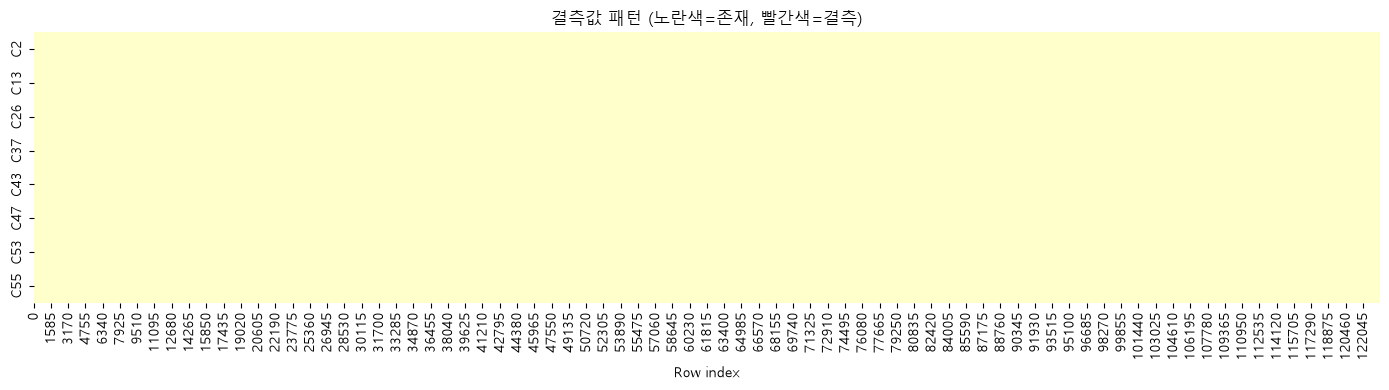

In [5]:
# 부분 결측이 있는 컬럼만 (0% < null < 100%)
partial_na = col_info[(col_info['null_pct'] > 0) & (col_info['null_pct'] < 100)]
print(f"부분 결측 컬럼: {partial_na.index.tolist()}")
print(partial_na[['null_count', 'null_pct']])

# 결측 패턴 히트맵 (전체 컬럼 중 결측 있는 것만)
na_cols = col_info[col_info['null_pct'] > 0].index.tolist()
if na_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(train[na_cols].isnull().T, cbar=False, cmap='YlOrRd', ax=ax)
    ax.set_title('결측값 패턴 (노란색=존재, 빨간색=결측)')
    ax.set_xlabel('Row index')
    plt.tight_layout()
    plt.show()
else:
    print("결측 컬럼 없음")

## 3. WF(C64) 그룹 구조 검증

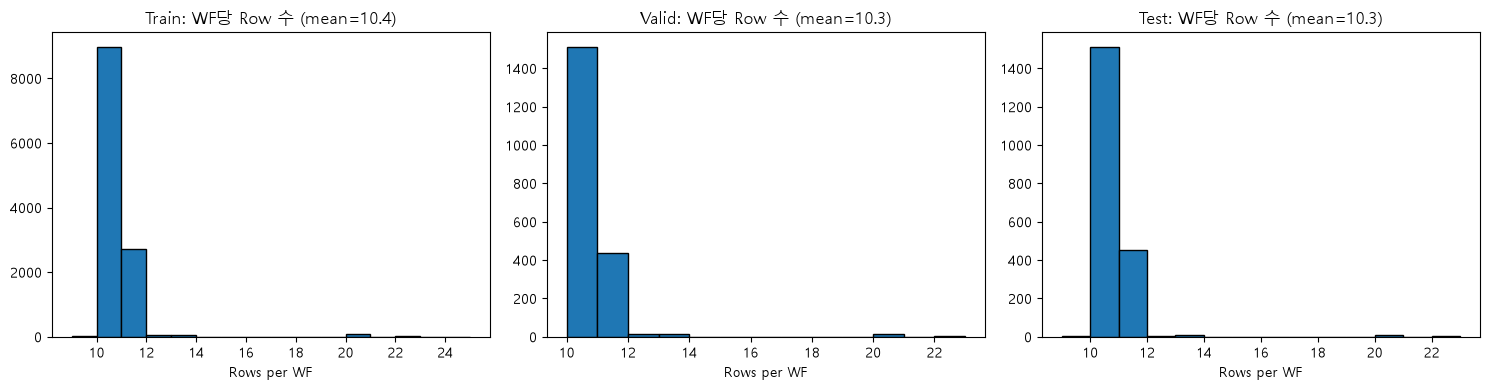

C65가 WF 내 상수인지: True  (모든 그룹 unique==1)
WF당 row 수 통계: min=9, max=24, median=10, std=1.12


In [6]:
# WF당 row 수 분포
rows_per_wf = train.groupby('C64').size()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# train
axes[0].hist(rows_per_wf, bins=range(rows_per_wf.min(), rows_per_wf.max()+2), edgecolor='black')
axes[0].set_title(f'Train: WF당 Row 수 (mean={rows_per_wf.mean():.1f})')
axes[0].set_xlabel('Rows per WF')

# valid
rpw_v = valid_X.groupby('C64').size()
axes[1].hist(rpw_v, bins=range(rpw_v.min(), rpw_v.max()+2), edgecolor='black')
axes[1].set_title(f'Valid: WF당 Row 수 (mean={rpw_v.mean():.1f})')
axes[1].set_xlabel('Rows per WF')

# test
rpw_t = test_X.groupby('C64').size()
axes[2].hist(rpw_t, bins=range(rpw_t.min(), rpw_t.max()+2), edgecolor='black')
axes[2].set_title(f'Test: WF당 Row 수 (mean={rpw_t.mean():.1f})')
axes[2].set_xlabel('Rows per WF')

plt.tight_layout()
plt.show()

# C65가 WF 내에서 상수인지 확인
c65_nunique = train.groupby('C64')['C65'].nunique()
print(f"C65가 WF 내 상수인지: {(c65_nunique == 1).all()}  (모든 그룹 unique==1)")
print(f"WF당 row 수 통계: min={rows_per_wf.min()}, max={rows_per_wf.max()}, "
      f"median={rows_per_wf.median():.0f}, std={rows_per_wf.std():.2f}")

## 4. 타깃(C65) 분포 분석

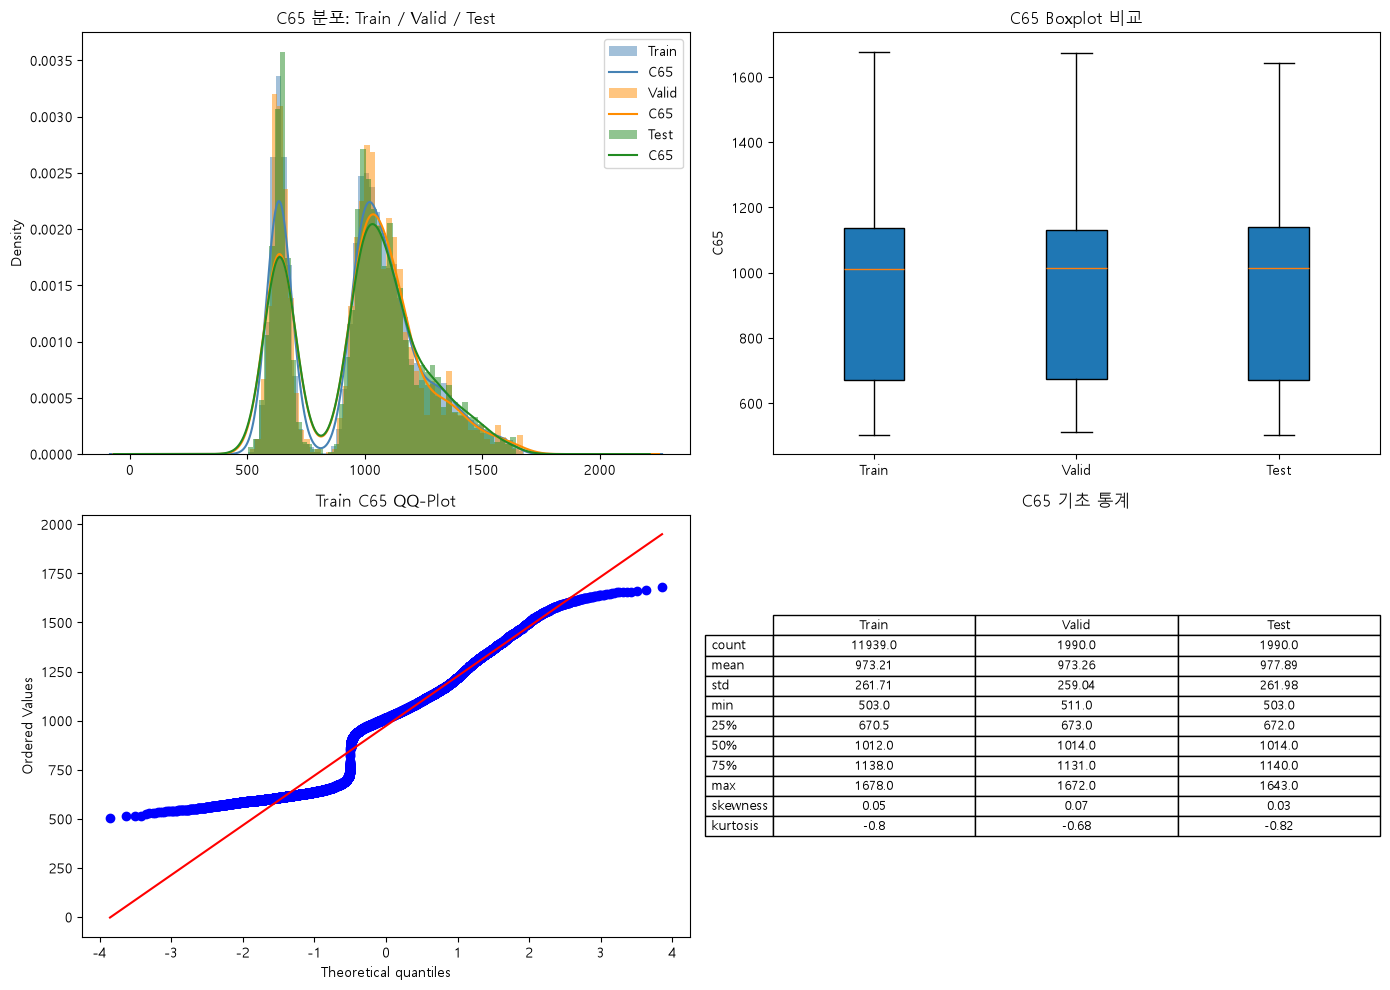

             Train    Valid     Test
count     11939.00  1990.00  1990.00
mean        973.21   973.26   977.89
std         261.71   259.04   261.98
min         503.00   511.00   503.00
25%         670.50   673.00   672.00
50%        1012.00  1014.00  1014.00
75%        1138.00  1131.00  1140.00
max        1678.00  1672.00  1643.00
skewness      0.05     0.07     0.03
kurtosis     -0.80    -0.68    -0.82


In [7]:
# WF 단위 타깃 (WF 내 상수이므로 first로 추출)
y_train_wf = train.groupby('C64')['C65'].first()
y_valid_wf = valid_Y_ans.set_index('C64')['C65']
y_test_wf  = test_Y_ans.set_index('C64')['C65']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 히스토그램 + KDE
for data, label, color in [(y_train_wf, 'Train', 'steelblue'),
                            (y_valid_wf, 'Valid', 'darkorange'),
                            (y_test_wf, 'Test', 'forestgreen')]:
    axes[0, 0].hist(data, bins=50, alpha=0.5, label=label, color=color, density=True)
    data.plot.kde(ax=axes[0, 0], color=color, lw=1.5)
axes[0, 0].set_title('C65 분포: Train / Valid / Test')
axes[0, 0].legend()

# Boxplot 비교
axes[0, 1].boxplot([y_train_wf, y_valid_wf, y_test_wf],
                    tick_labels=['Train', 'Valid', 'Test'], patch_artist=True)
axes[0, 1].set_title('C65 Boxplot 비교')
axes[0, 1].set_ylabel('C65')

# QQ-plot (정규성 확인 — train)
stats.probplot(y_train_wf, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Train C65 QQ-Plot')

# 기초통계
stats_df = pd.DataFrame({
    'Train': y_train_wf.describe(),
    'Valid': y_valid_wf.describe(),
    'Test':  y_test_wf.describe(),
})
stats_df.loc['skewness'] = [y_train_wf.skew(), y_valid_wf.skew(), y_test_wf.skew()]
stats_df.loc['kurtosis'] = [y_train_wf.kurtosis(), y_valid_wf.kurtosis(), y_test_wf.kurtosis()]
axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=stats_df.round(2).values,
    rowLabels=stats_df.index,
    colLabels=stats_df.columns,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[1, 1].set_title('C65 기초 통계')

plt.tight_layout()
plt.show()

print(stats_df.round(2))

## 5. 시간 축 분석 (Temporal Drift)

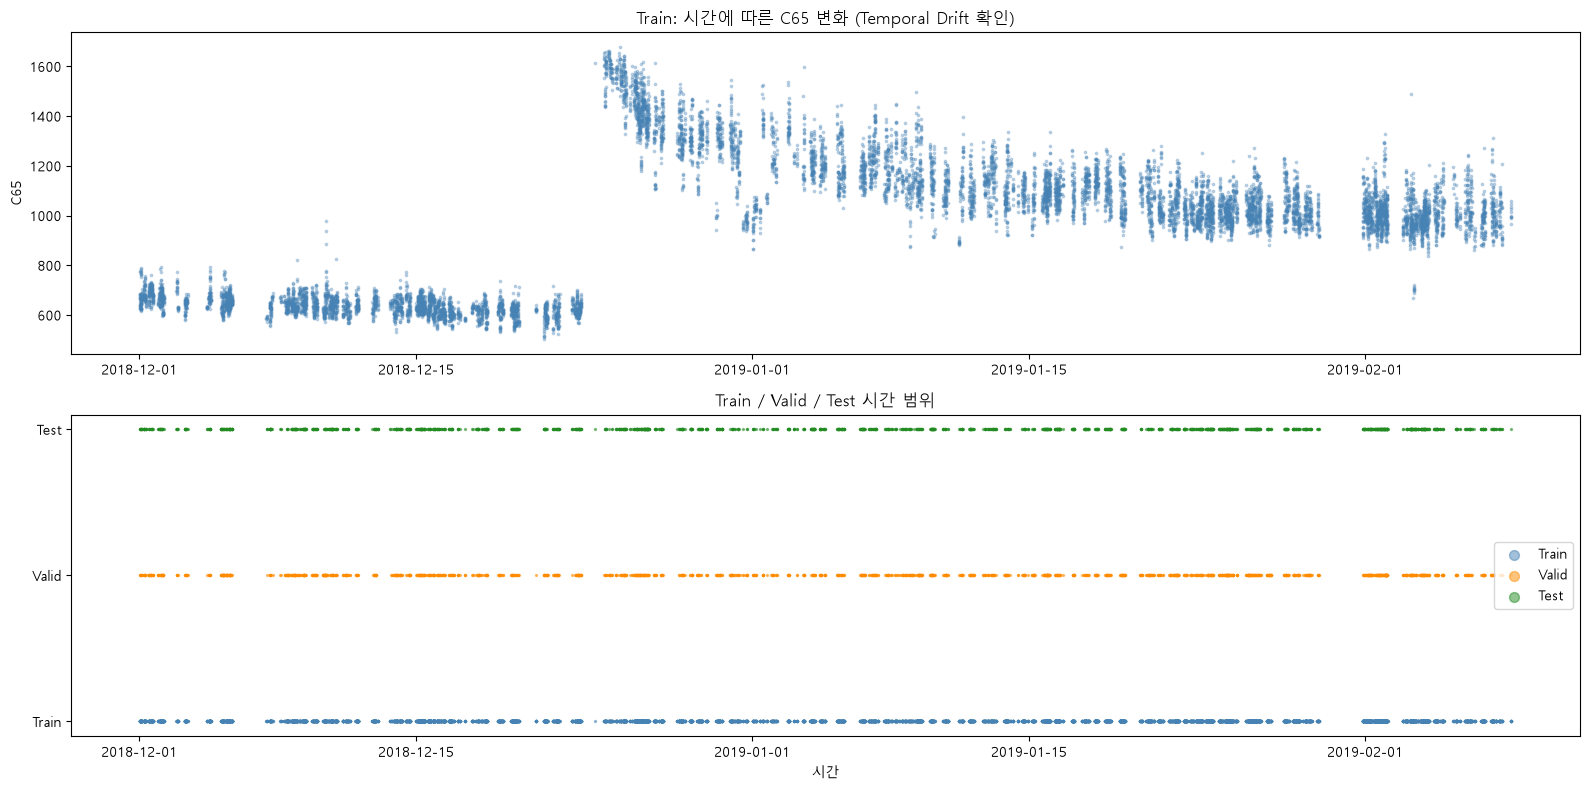

Train: 2018-12-01 00:44:06.700000 ~ 2019-02-08 09:43:02.900000
Valid: 2018-12-01 00:46:06.700000 ~ 2019-02-08 09:41:08.900000
Test: 2018-12-01 00:57:31.600000 ~ 2019-02-08 09:35:29.700000


In [8]:
# WF 단위: 첫 번째 C40_dt를 대표 시간으로
train_wf = train.groupby('C64').agg(
    time=('C40_dt', 'first'),
    C65=('C65', 'first')
).sort_values('time')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Train: 시간 vs C65
axes[0].scatter(train_wf['time'], train_wf['C65'], s=3, alpha=0.3, c='steelblue')
axes[0].set_title('Train: 시간에 따른 C65 변화 (Temporal Drift 확인)')
axes[0].set_ylabel('C65')

# Train / Valid / Test 시간 범위 비교
for name, df, color in [('Train', train, 'steelblue'),
                         ('Valid', valid_X, 'darkorange'),
                         ('Test', test_X, 'forestgreen')]:
    wf_time = df.groupby('C64')['C40_dt'].first().sort_values()
    axes[1].scatter(wf_time.values, [name]*len(wf_time), s=2, alpha=0.5, c=color, label=name)
axes[1].set_title('Train / Valid / Test 시간 범위')
axes[1].set_xlabel('시간')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

# 시간 순서 겹침 여부 확인
for name, df in [('Train', train), ('Valid', valid_X), ('Test', test_X)]:
    t_min = df['C40_dt'].min()
    t_max = df['C40_dt'].max()
    print(f"{name}: {t_min} ~ {t_max}")

## 6. Train vs Valid vs Test 분포 비교 (Covariate Shift)\nAdversarial Validation: train과 valid/test를 구분하는 분류 모델의 AUC가 0.5에 가까우면 분포 동질, 1.0에 가까우면 큰 shift.

In [10]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

# WF 단위 평균 집계 (수치형만, ID/시간/범주 제외)
drop_for_adv = ['C64', 'C34', 'C35', 'C38', 'C20', 'C21', 'C22',
                'C14', 'C24', 'C6', 'C40', 'C40_dt', 'C10_dt', 'C39_dt',
                'C26', 'C28', 'C29', 'C37',
                'C2', 'C13', 'C43', 'C47', 'C53', 'C55', 'C65']

def wf_mean(df):
    num = df.drop(columns=[c for c in drop_for_adv if c in df.columns], errors='ignore')
    return num.groupby(df['C64']).mean(numeric_only=True).reset_index(drop=True)

tr_agg = wf_mean(train)
vl_agg = wf_mean(valid_X)
ts_agg = wf_mean(test_X)

def adversarial_auc(df1, df2, label1='train', label2='other'):
    combined = pd.concat([df1.assign(is_other=0), df2.assign(is_other=1)], ignore_index=True)
    y = combined['is_other'].values
    X = combined.drop(columns='is_other').fillna(-999).values

    aucs = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for tr_idx, val_idx in skf.split(X, y):
        clf = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31,
                                  verbose=-1, random_state=42)
        clf.fit(X[tr_idx], y[tr_idx])
        aucs.append(roc_auc_score(y[val_idx], clf.predict_proba(X[val_idx])[:, 1]))
    return np.mean(aucs)

auc_tv = adversarial_auc(tr_agg, vl_agg, 'train', 'valid')
auc_tt = adversarial_auc(tr_agg, ts_agg, 'train', 'test')
auc_vt = adversarial_auc(vl_agg, ts_agg, 'valid', 'test')

print("Adversarial Validation AUC (0.5=동질, 1.0=완전 분리):")
print(f"  Train vs Valid : {auc_tv:.4f}")
print(f"  Train vs Test  : {auc_tt:.4f}")
print(f"  Valid vs Test  : {auc_vt:.4f}")

Adversarial Validation AUC (0.5=동질, 1.0=완전 분리):
  Train vs Valid : 0.5103
  Train vs Test  : 0.5008
  Valid vs Test  : 0.4970


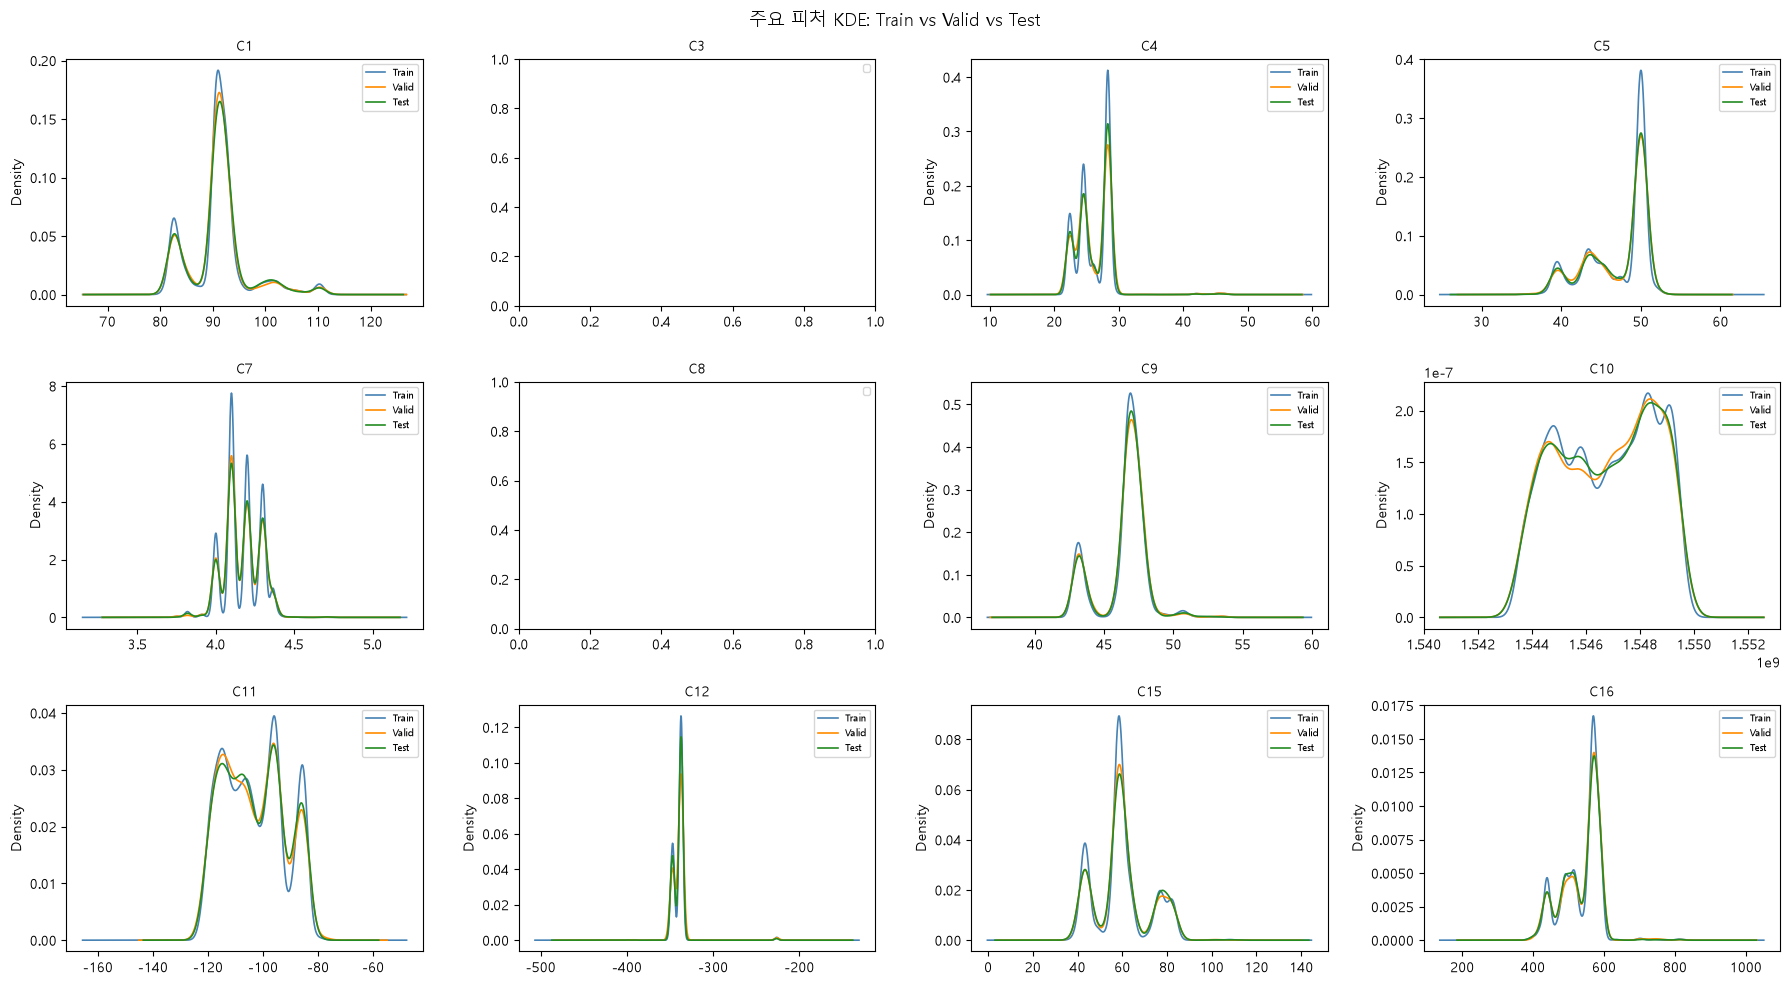

In [12]:
# 주요 수치형 컬럼 KDE 오버레이 (상위 12개)
num_cols_common = [c for c in tr_agg.columns if c in vl_agg.columns and c in ts_agg.columns]
sample_cols = num_cols_common[:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col in zip(axes.flatten(), sample_cols):
    for data, label, color in [(tr_agg, 'Train', 'steelblue'),
                                (vl_agg, 'Valid', 'darkorange'),
                                (ts_agg, 'Test', 'forestgreen')]:
        if col in data.columns:
            s = data[col].dropna()
            if s.nunique() > 1:
                try:
                    s.plot.kde(ax=ax, label=label, color=color, lw=1.2)
                except Exception:
                    pass
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('주요 피처 KDE: Train vs Valid vs Test', fontsize=13)
plt.tight_layout()
plt.show()

## 7. 피처-타깃 상관관계

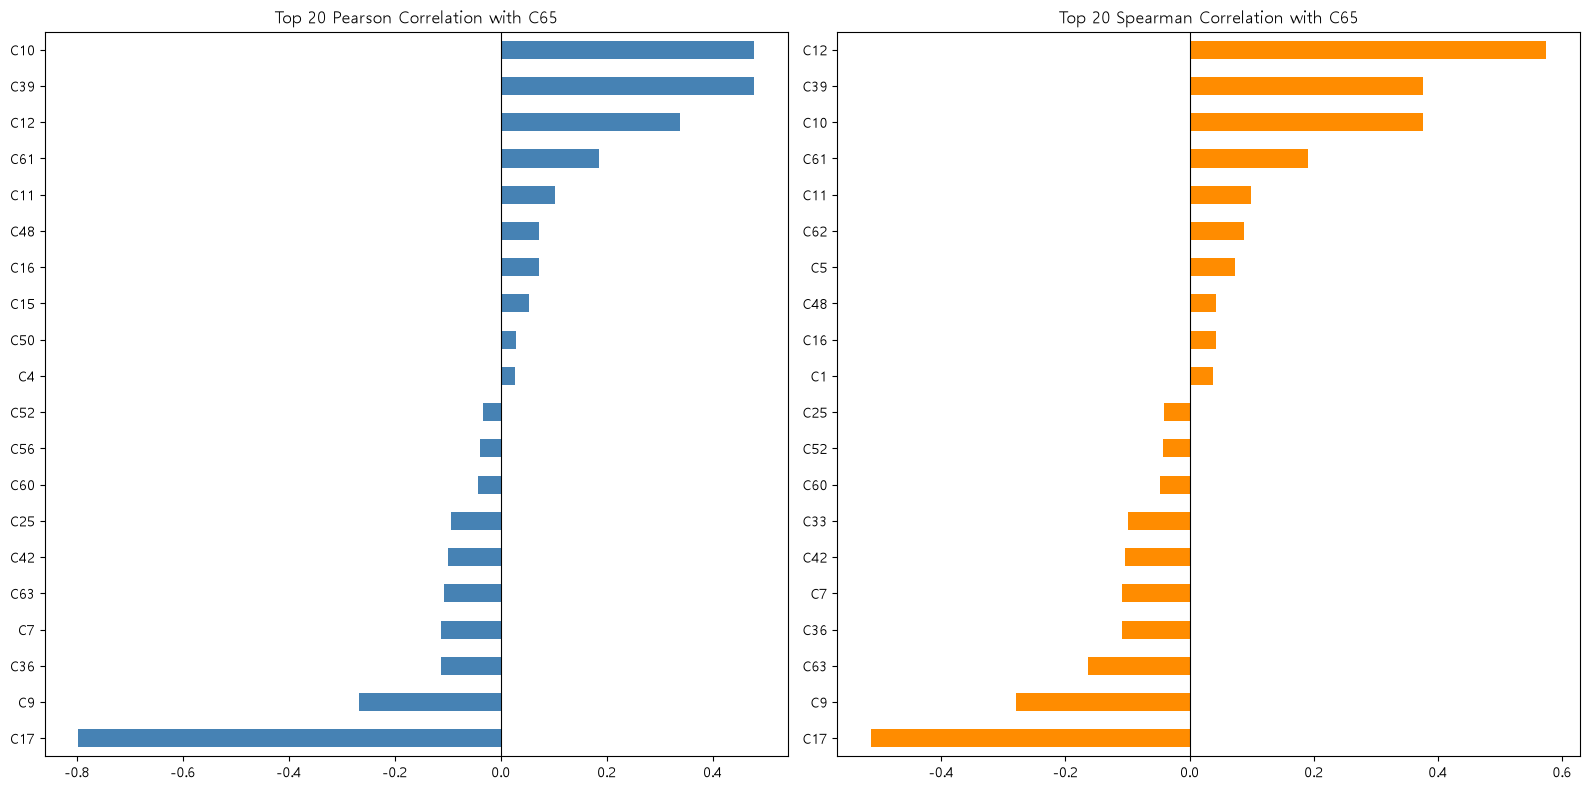

|Pearson| > 0.3인 피처 (4개):
C17   -0.797
C10    0.478
C39    0.478
C12    0.338


In [13]:
# WF 단위 평균 집계 + C65 포함
tr_with_y = tr_agg.copy()
tr_with_y['C65'] = train.groupby('C64')['C65'].first().values

# Pearson & Spearman 상관계수
pearson_corr  = tr_with_y.corr(method='pearson')['C65'].drop('C65').sort_values(key=abs, ascending=False)
spearman_corr = tr_with_y.corr(method='spearman')['C65'].drop('C65').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 Pearson
pearson_corr.head(20).sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Pearson Correlation with C65')
axes[0].axvline(x=0, color='black', lw=0.8)

# Top 20 Spearman
spearman_corr.head(20).sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Top 20 Spearman Correlation with C65')
axes[1].axvline(x=0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

# 상관계수 > 0.3인 피처 목록
strong = pearson_corr[pearson_corr.abs() > 0.3]
print(f"|Pearson| > 0.3인 피처 ({len(strong)}개):")
print(strong.round(3).to_string())

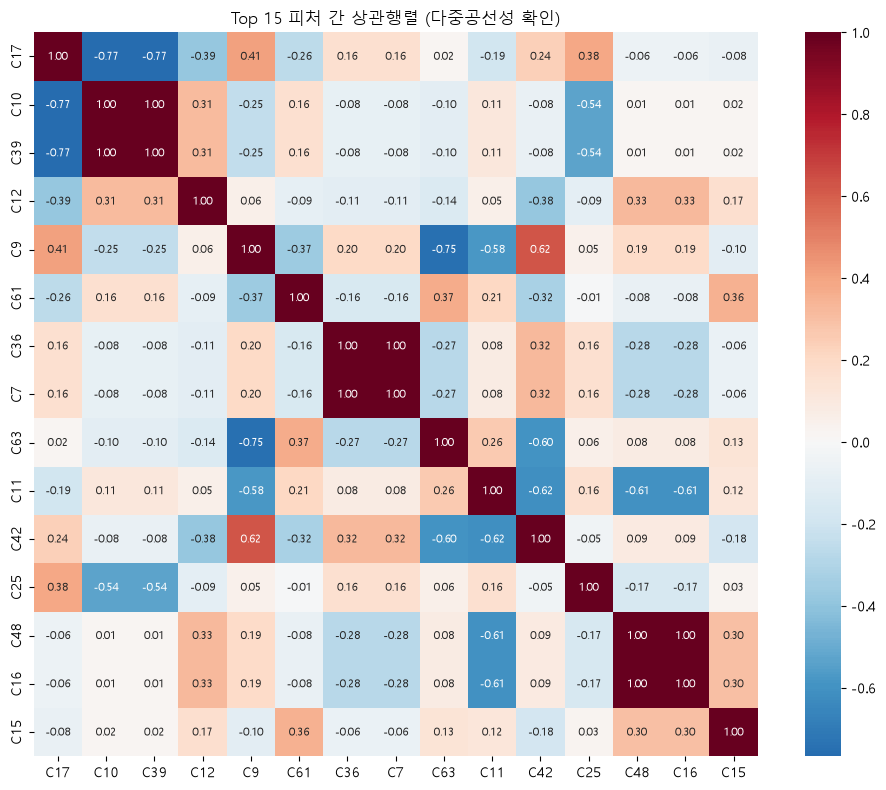

In [14]:
# 다중공선성 확인 — 상위 상관 피처 간 히트맵
top_feats = pearson_corr.head(15).index.tolist()
corr_matrix = tr_with_y[top_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Top 15 피처 간 상관행렬 (다중공선성 확인)')
plt.tight_layout()
plt.show()

## 8. PM(C33) 영향 분석

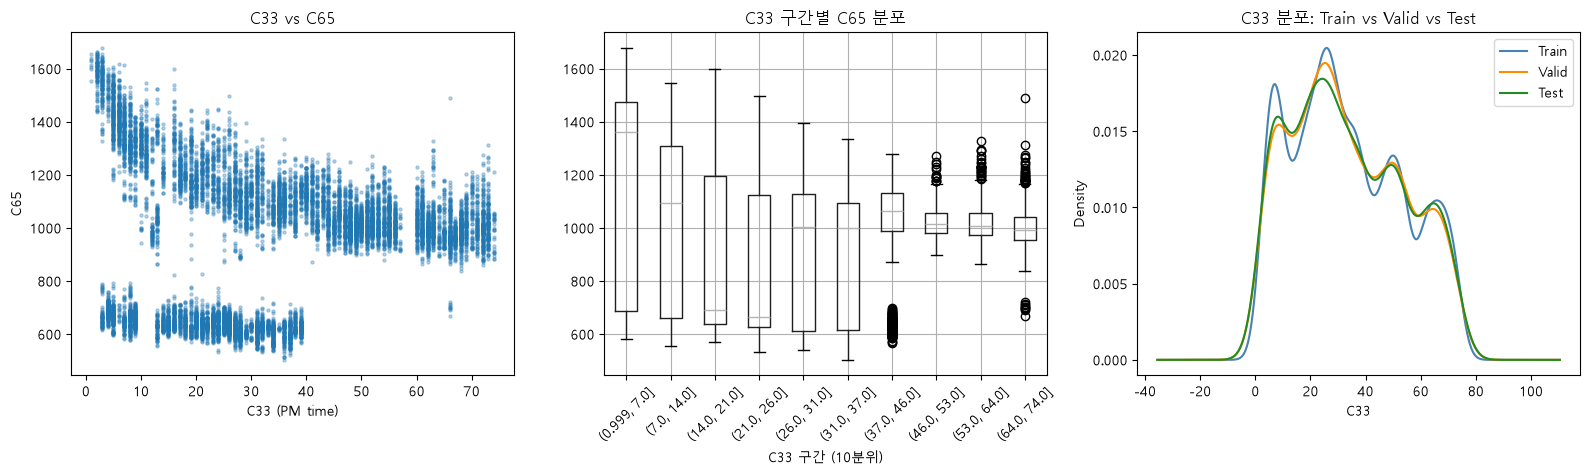

C33 ↔ C65 Pearson 상관계수: -0.0130


In [15]:
# WF 단위 C33 대표값 (first)
train_pm = train.groupby('C64').agg(C33=('C33', 'first'), C65=('C65', 'first'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter
axes[0].scatter(train_pm['C33'], train_pm['C65'], s=5, alpha=0.3)
axes[0].set_xlabel('C33 (PM time)')
axes[0].set_ylabel('C65')
axes[0].set_title('C33 vs C65')

# C33 구간별 boxplot
train_pm['C33_bin'] = pd.qcut(train_pm['C33'], q=10, duplicates='drop')
train_pm.boxplot(column='C65', by='C33_bin', ax=axes[1], rot=45)
axes[1].set_title('C33 구간별 C65 분포')
axes[1].set_xlabel('C33 구간 (10분위)')
plt.sca(axes[1])
plt.title('C33 구간별 C65 분포')
plt.suptitle('')

# C33 분포: train vs valid vs test
for name, df, color in [('Train', train, 'steelblue'),
                         ('Valid', valid_X, 'darkorange'),
                         ('Test', test_X, 'forestgreen')]:
    c33_wf = df.groupby('C64')['C33'].first()
    c33_wf.plot.kde(ax=axes[2], label=name, color=color, lw=1.5)
axes[2].set_title('C33 분포: Train vs Valid vs Test')
axes[2].set_xlabel('C33')
axes[2].legend()

plt.tight_layout()
plt.show()

corr_c33 = train_pm['C33'].corr(train_pm['C65'])
print(f"C33 ↔ C65 Pearson 상관계수: {corr_c33:.4f}")

## 9. 이상치 탐지

C65 IQR 이상치: 0개 / 11939개 (0.00%)
  범위: [-30.8, 1839.2], 이상치 범위: [nan, nan]


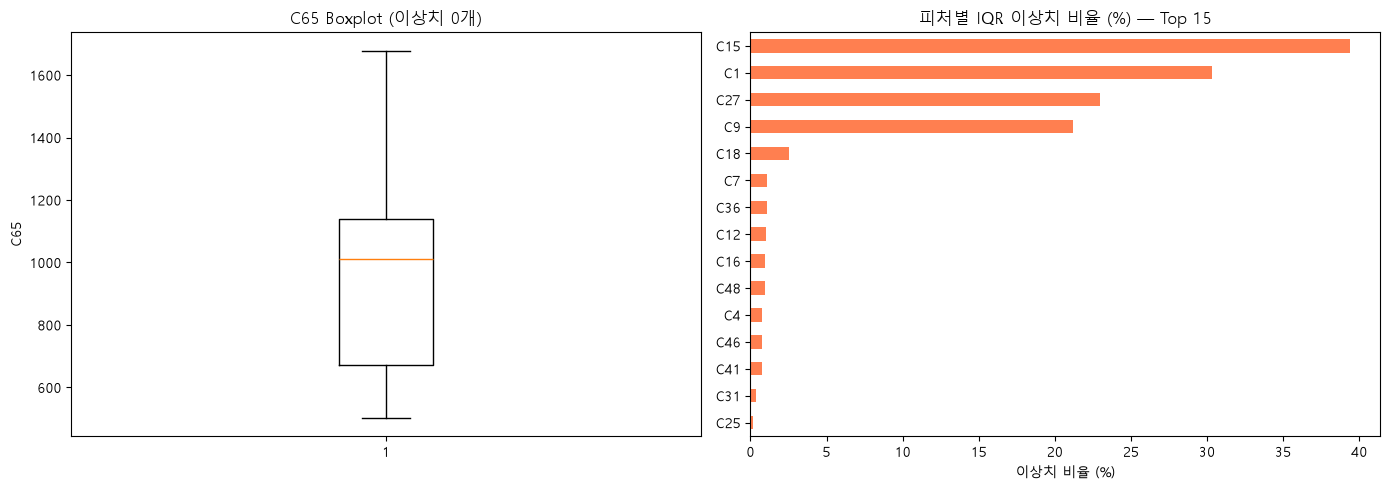

In [16]:
# C65 이상치 (IQR)
Q1, Q3 = y_train_wf.quantile(0.25), y_train_wf.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = y_train_wf[(y_train_wf < lower) | (y_train_wf > upper)]
print(f"C65 IQR 이상치: {len(outliers)}개 / {len(y_train_wf)}개 ({len(outliers)/len(y_train_wf)*100:.2f}%)")
print(f"  범위: [{lower:.1f}, {upper:.1f}], 이상치 범위: [{outliers.min():.1f}, {outliers.max():.1f}]")

# 주요 수치형 피처 이상치 비율
outlier_rates = {}
for col in tr_agg.columns[:30]:
    s = tr_agg[col].dropna()
    if len(s) < 10:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100
    outlier_rates[col] = out

outlier_df = pd.Series(outlier_rates).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C65 boxplot
axes[0].boxplot(y_train_wf, vert=True)
axes[0].set_title(f'C65 Boxplot (이상치 {len(outliers)}개)')
axes[0].set_ylabel('C65')

# 피처별 이상치 비율
outlier_df.head(15).sort_values().plot.barh(ax=axes[1], color='coral')
axes[1].set_title('피처별 IQR 이상치 비율 (%) — Top 15')
axes[1].set_xlabel('이상치 비율 (%)')

plt.tight_layout()
plt.show()

## 10. 범주형(C6, C7) × 타깃 교호작용

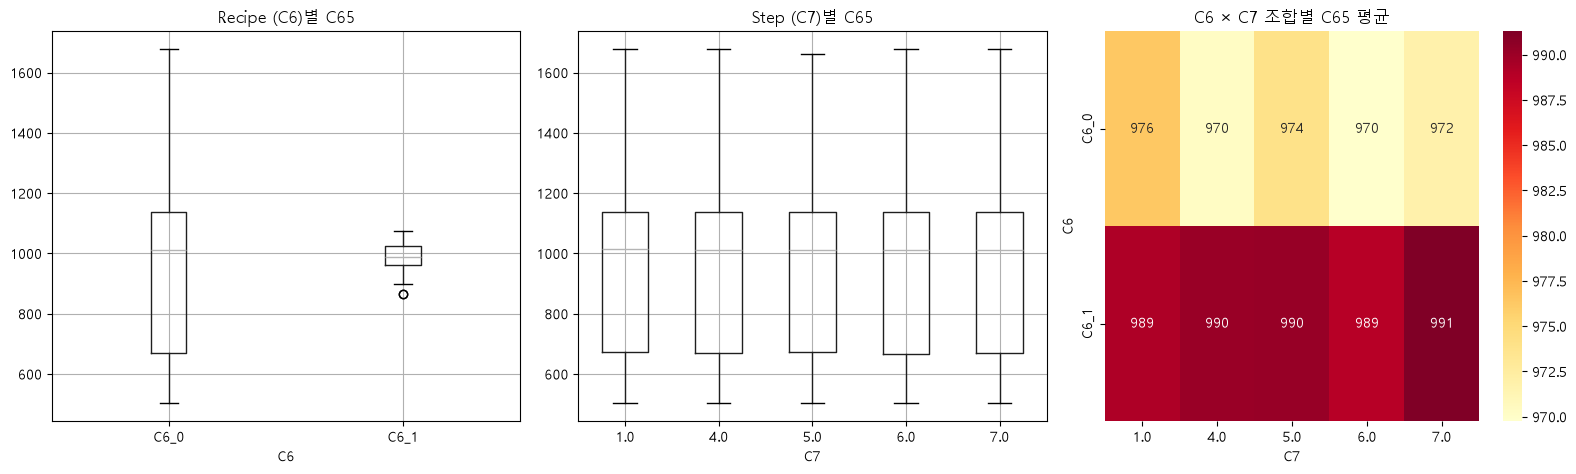

C6 분포 비교:
  Train: {'C6_0': np.float64(0.992), 'C6_1': np.float64(0.008)}
  Valid: {'C6_0': np.float64(0.991), 'C6_1': np.float64(0.009)}
  Test: {'C6_0': np.float64(0.995), 'C6_1': np.float64(0.005)}

C7 분포 비교:
  Train: {1.0: np.float64(0.21), 4.0: np.float64(0.458), 5.0: np.float64(0.034), 6.0: np.float64(0.136), 7.0: np.float64(0.162)}
  Valid: {1.0: np.float64(0.21), 4.0: np.float64(0.458), 5.0: np.float64(0.034), 6.0: np.float64(0.137), 7.0: np.float64(0.162)}
  Test: {1.0: np.float64(0.21), 4.0: np.float64(0.457), 5.0: np.float64(0.034), 6.0: np.float64(0.136), 7.0: np.float64(0.163)}


In [17]:
# WF 단위 범주 대표값
train_cat = train.groupby('C64').agg(
    C6=('C6', 'first'),
    C7_mode=('C7', lambda x: x.mode().iloc[0]),
    C65=('C65', 'first')
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# C6별 C65
train_cat.boxplot(column='C65', by='C6', ax=axes[0])
axes[0].set_title('Recipe (C6)별 C65')
plt.sca(axes[0])
plt.suptitle('')

# C7별 C65 (모든 row 기준 — step별로 다른 의미)
train.boxplot(column='C65', by='C7', ax=axes[1])
axes[1].set_title('Step (C7)별 C65')
plt.sca(axes[1])
plt.suptitle('')

# C6 × C7 조합별 C65 평균
cross = train.groupby(['C6', 'C7'])['C65'].agg(['mean', 'std', 'count']).reset_index()
cross_pivot = cross.pivot(index='C6', columns='C7', values='mean')
sns.heatmap(cross_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('C6 × C7 조합별 C65 평균')

plt.tight_layout()
plt.show()

# C6, C7 분포: train vs valid vs test
print("C6 분포 비교:")
for name, df in [('Train', train), ('Valid', valid_X), ('Test', test_X)]:
    dist = df.groupby('C64')['C6'].first().value_counts(normalize=True)
    print(f"  {name}: {dict(dist.round(3))}")

print("\nC7 분포 비교:")
for name, df in [('Train', train), ('Valid', valid_X), ('Test', test_X)]:
    dist = df['C7'].value_counts(normalize=True).sort_index()
    print(f"  {name}: {dict(dist.round(3))}")

## EDA 요약 & 다음 단계
### 노트북 실행 후 아래 항목을 확인하고 전처리 방향을 결정:
| # | 검증 항목 | 확인할 것 | 전처리 영향 |
|---|----------|----------|------------|
| 1 | 컬럼 타입·상수 | 상수/전부결측 컬럼 제거 대상 확정 | Drop list |
| 2 | 결측 패턴 | 부분 결측이 랜덤인지 구조적인지 | 결측 처리 전략 (fill vs indicator) |
| 3 | WF 그룹 구조 | row 수 편차, C65 상수 여부 | 집계 신뢰도 |
| 4 | C65 분포 | 정규성, skewness → 로그변환 필요? | 타깃 변환 |
| 5 | Temporal drift | train→valid→test 시간 순서·겹침 | 시간 변수 처리, CV 전략 |
| 6 | Covariate shift | Adversarial AUC 값 | shift 크면 도메인 적응 필요 |
| 7 | 상관관계 | 유의미 피처 Top-N, 다중공선성 | 피처 선택 |
| 8 | PM(C33) | C33↔C65 관계 강도 | PM 관련 파생 피처 |
| 9 | 이상치 | C65 및 센서 이상치 비율 | 클리핑/로버스트 스케일링 |
| 10 | 범주형 교호 | C6·C7별 C65 차이, 분포 동질성 | 그룹별 모델링 여부 |